In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("C:/Users/Hari balaji M/Downloads/ev_charging_patterns.csv")
df.head()

,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),Time of Day,Day of Week,State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type
0,User_1,BMW i3,108.463007,Station_391,Houston,2024-01-01 00:00:00,2024-01-01 00:39:00,60.712346,0.591363,36.389181,13.087717,Evening,Tuesday,29.371576,86.119962,293.602111,27.947953,2.0,DC Fast Charger,Commuter
1,User_2,Hyundai Kona,100.000000,Station_428,San Francisco,2024-01-01 01:00:00,2024-01-01 03:01:00,12.339275,3.133652,30.677735,21.128448,Morning,Monday,10.115778,84.664344,112.112804,14.311026,3.0,Level 1,Casual Driver
2,User_3,Chevy Bolt,75.000000,Station_181,San Francisco,2024-01-01 02:00:00,2024-01-01 04:48:00,19.128876,2.452653,27.513593,35.667270,Morning,Thursday,6.854604,69.917615,71.799253,21.002002,2.0,Level 2,Commuter
3,User_4,Hyundai Kona,50.000000,Station_327,Houston,2024-01-01 03:00:00,2024-01-01 06:42:00,79.457824,1.266431,32.882870,13.036239,Evening,Saturday,83.120003,99.624328,199.577785,38.316313,1.0,Level 1,Long-Distance Traveler
4,User_5,Hyundai Kona,50.000000,Station_108,Los Angeles,2024-01-01 04:00:00,2024-01-01 05:46:00,19.629104,2.019765,10.215712,10.161471,Morning,Saturday,54.258950,63.743786,203.661847,-7.834199,1.0,Level 1,Long-Distance Traveler


In [5]:
df.tail()

,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),Time of Day,Day of Week,State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type
1315,User_1316,Nissan Leaf,100.000000,Station_57,New York,2024-02-24 19:00:00,2024-02-24 20:30:00,42.011654,1.426444,5.895475,22.081164,Evening,Sunday,39.204102,83.915952,239.601075,1.919655,7.0,DC Fast Charger,Commuter
1316,User_1317,BMW i3,100.000000,Station_40,New York,2024-02-24 20:00:00,2024-02-24 20:44:00,68.185853,3.238212,18.388012,5.067806,Evening,Tuesday,31.456375,93.096461,164.376022,34.029775,4.0,Level 2,Casual Driver
1317,User_1318,Nissan Leaf,100.000000,Station_374,New York,2024-02-24 21:00:00,2024-02-24 23:03:00,18.895102,3.267122,45.482066,37.255002,Evening,Tuesday,71.903081,78.678879,226.519258,20.358761,5.0,DC Fast Charger,Commuter
1318,User_1319,Chevy Bolt,85.000000,Station_336,San Francisco,2024-02-24 22:00:00,2024-02-24 23:20:00,13.756252,2.754527,38.148183,39.046146,Afternoon,Sunday,76.187997,65.926573,291.494076,24.134598,5.0,Level 2,Commuter
1319,User_1320,Nissan Leaf,120.447195,Station_128,Los Angeles,2024-02-24 23:00:00,2024-02-24 23:56:00,63.652570,3.740970,33.704226,10.863674,Evening,Monday,59.338076,56.692439,14.449236,-6.966593,5.0,DC Fast Charger,Commuter


In [5]:
df.shape

(1320, 20)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   User ID                                   1320 non-null   object 
 1   Vehicle Model                             1320 non-null   object 
 2   Battery Capacity (kWh)                    1320 non-null   float64
 3   Charging Station ID                       1320 non-null   object 
 4   Charging Station Location                 1320 non-null   object 
 5   Charging Start Time                       1320 non-null   object 
 6   Charging End Time                         1320 non-null   object 
 7   Energy Consumed (kWh)                     1254 non-null   float64
 8   Charging Duration (hours)                 1320 non-null   float64
 9   Charging Rate (kW)                        1254 non-null   float64
 10  Charging Cost (USD)                 

In [37]:
df["Vehicle Model"].unique()

array(['BMW i3', 'Hyundai Kona', 'Chevy Bolt', 'Nissan Leaf',
       'Tesla Model 3'], dtype=object)

In [13]:
df["Charging Station Location"].unique()

array(['Houston', 'San Francisco', 'Los Angeles', 'Chicago', 'New York'],
      dtype=object)

In [15]:
df["Charging Start Time"] = pd.to_datetime(
    df["Charging Start Time"]
)

df["Charging End Time"] = pd.to_datetime(
    df["Charging End Time"]
)


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   User ID                                   1320 non-null   object        
 1   Vehicle Model                             1320 non-null   object        
 2   Battery Capacity (kWh)                    1320 non-null   float64       
 3   Charging Station ID                       1320 non-null   object        
 4   Charging Station Location                 1320 non-null   object        
 5   Charging Start Time                       1320 non-null   datetime64[ns]
 6   Charging End Time                         1320 non-null   datetime64[ns]
 7   Energy Consumed (kWh)                     1254 non-null   float64       
 8   Charging Duration (hours)                 1320 non-null   float64       
 9   Charging Rate (kW)            

In [13]:
df.isnull().sum()

User ID                                      0
Vehicle Model                                0
Battery Capacity (kWh)                       0
Charging Station ID                          0
Charging Station Location                    0
Charging Start Time                          0
Charging End Time                            0
Energy Consumed (kWh)                       66
Charging Duration (hours)                    0
Charging Rate (kW)                          66
Charging Cost (USD)                          0
Time of Day                                  0
Day of Week                                  0
State of Charge (Start %)                    0
State of Charge (End %)                      0
Distance Driven (since last charge) (km)    66
Temperature (°C)                             0
Vehicle Age (years)                          0
Charger Type                                 0
User Type                                    0
dtype: int64

In [8]:
df[[
    "Energy Consumed (kWh)",
    "Charging Rate (kW)",
    "Charging Duration (hours)",
    "Distance Driven (since last charge) (km)"
]].corr()


,Energy Consumed (kWh),Charging Rate (kW),Charging Duration (hours),Distance Driven (since last charge) (km)
Energy Consumed (kWh),1.000000,-0.042610,0.028369,-0.027948
Charging Rate (kW),-0.042610,1.000000,-0.013460,0.032209
Charging Duration (hours),0.028369,-0.013460,1.000000,0.023644
Distance Driven (since last charge) (km),-0.027948,0.032209,0.023644,1.000000


In [13]:
df["Energy Consumed (kWh)"].median()

42.69140537961698

In [15]:
df["Energy Consumed (kWh)"].mean()

42.64289425435557

In [17]:
df["Charging Rate (kW)"].median()

25.603799331857445

In [19]:
df["Charging Rate (kW)"].mean()

25.96300342597954

In [23]:
df["Distance Driven (since last charge) (km)"].mean()

153.59678773584358

In [21]:
df["Distance Driven (since last charge) (km)"].median()

152.25986699080715

In [12]:
df["Energy Consumed (kWh)"] = df["Energy Consumed (kWh)"].fillna(
    df["Energy Consumed (kWh)"].median())

df["Charging Rate (kW)"] = df["Charging Rate (kW)"].fillna(
    df["Charging Rate (kW)"].median())

df["Distance Driven (since last charge) (km)"] = df[
    "Distance Driven (since last charge) (km)"
].fillna(
    df["Distance Driven (since last charge) (km)"].median())


In [14]:
df.isnull().sum()

User ID                                     0
Vehicle Model                               0
Battery Capacity (kWh)                      0
Charging Station ID                         0
Charging Station Location                   0
Charging Start Time                         0
Charging End Time                           0
Energy Consumed (kWh)                       0
Charging Duration (hours)                   0
Charging Rate (kW)                          0
Charging Cost (USD)                         0
Time of Day                                 0
Day of Week                                 0
State of Charge (Start %)                   0
State of Charge (End %)                     0
Distance Driven (since last charge) (km)    0
Temperature (°C)                            0
Vehicle Age (years)                         0
Charger Type                                0
User Type                                   0
dtype: int64

In [16]:
num_cols= df.select_dtypes(include='number').columns
num_cols


Index(['Battery Capacity (kWh)', 'Energy Consumed (kWh)',
       'Charging Duration (hours)', 'Charging Rate (kW)',
       'Charging Cost (USD)', 'State of Charge (Start %)',
       'State of Charge (End %)', 'Distance Driven (since last charge) (km)',
       'Temperature (°C)', 'Vehicle Age (years)'],
      dtype='object')

Text(0.5, 1.0, 'Outlier Detection Using Boxplots')

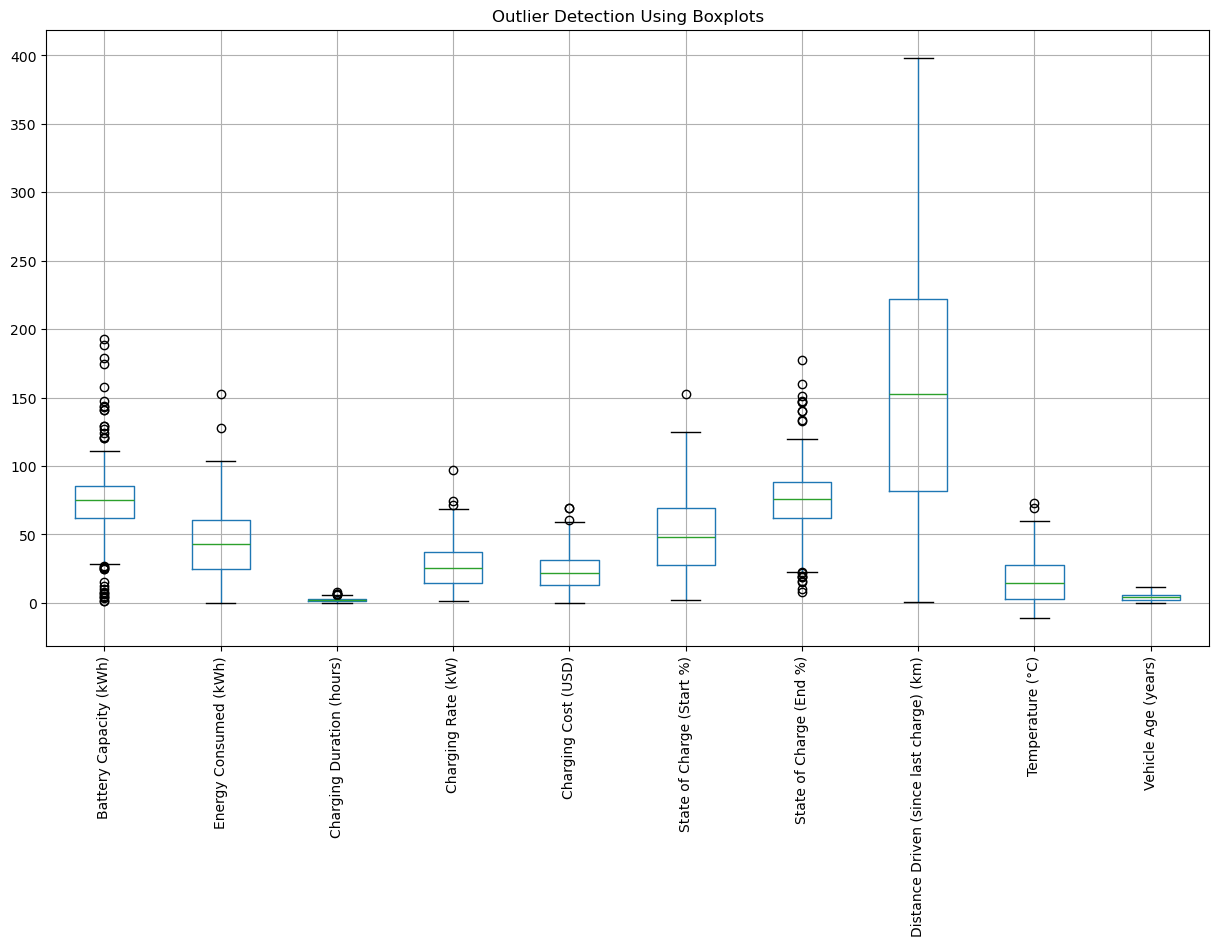

In [18]:
plt.figure(figsize=(15, 8))
df[num_cols].boxplot()
plt.xticks(rotation=90)
plt.title("Outlier Detection Using Boxplots")


In [20]:
df.loc[df["State of Charge (Start %)"] < 0, "State of Charge (Start %)"] = 0
df.loc[df["State of Charge (Start %)"] > 100, "State of Charge (Start %)"] = 100

df.loc[df["State of Charge (End %)"] < 0, "State of Charge (End %)"] = 0
df.loc[df["State of Charge (End %)"] > 100, "State of Charge (End %)"] = 100

Text(0.5, 1.0, 'Outlier Detection Using Boxplots')

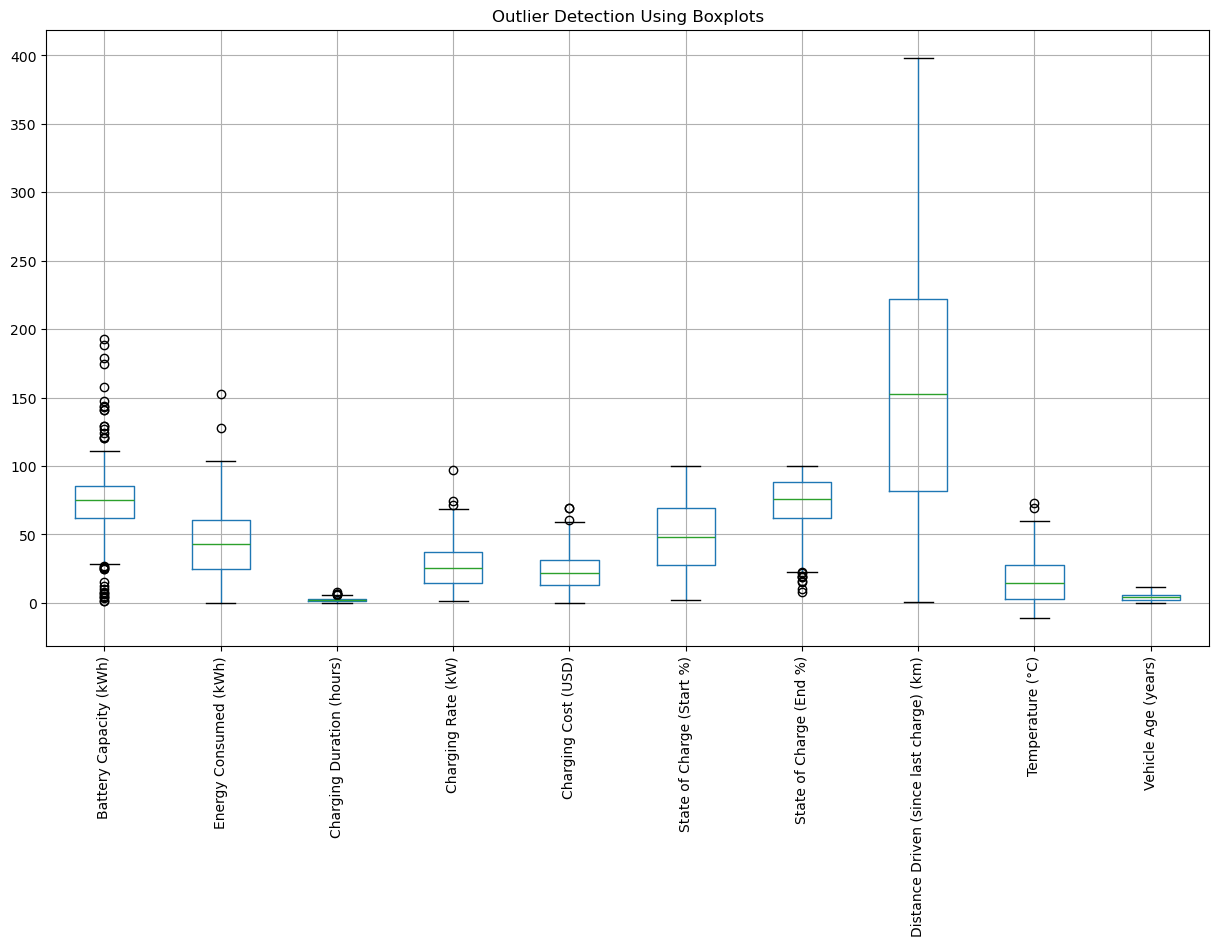

In [22]:
plt.figure(figsize=(15, 8))
df[num_cols].boxplot()
plt.xticks(rotation=90)
plt.title("Outlier Detection Using Boxplots")


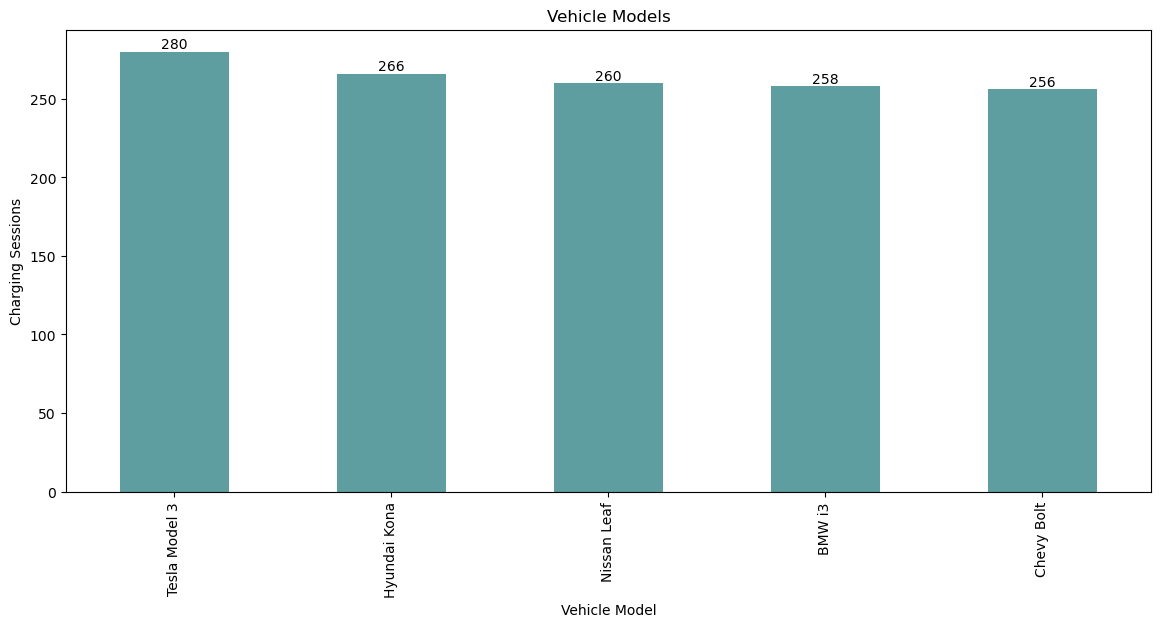

In [5]:
plt.figure(figsize=(14,6))  

ax = df["Vehicle Model"].value_counts().head(10).plot(
    kind="bar",
    color="#5F9EA0"
)

plt.title("Vehicle Models")
plt.xlabel("Vehicle Model")
plt.ylabel("Charging Sessions")

for i in ax.containers:
    ax.bar_label(i)

plt.show()


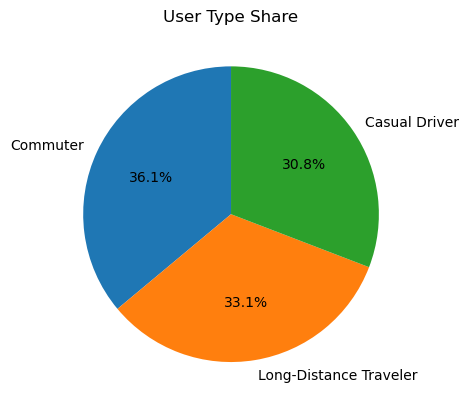

In [26]:
df["User Type"].value_counts().plot(kind="pie", autopct="%1.1f%%",startangle=90)
plt.title("User Type Share")
plt.ylabel("")
plt.show()


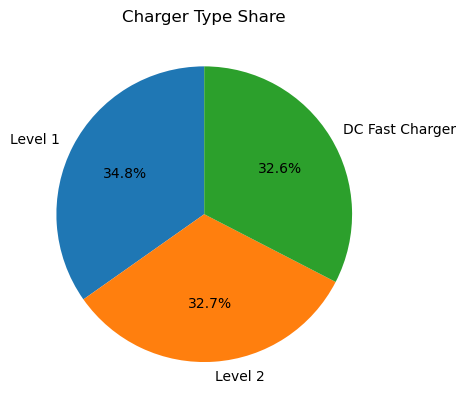

In [84]:
df["Charger Type"].value_counts().plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Charger Type Share")
plt.ylabel("")
plt.show()


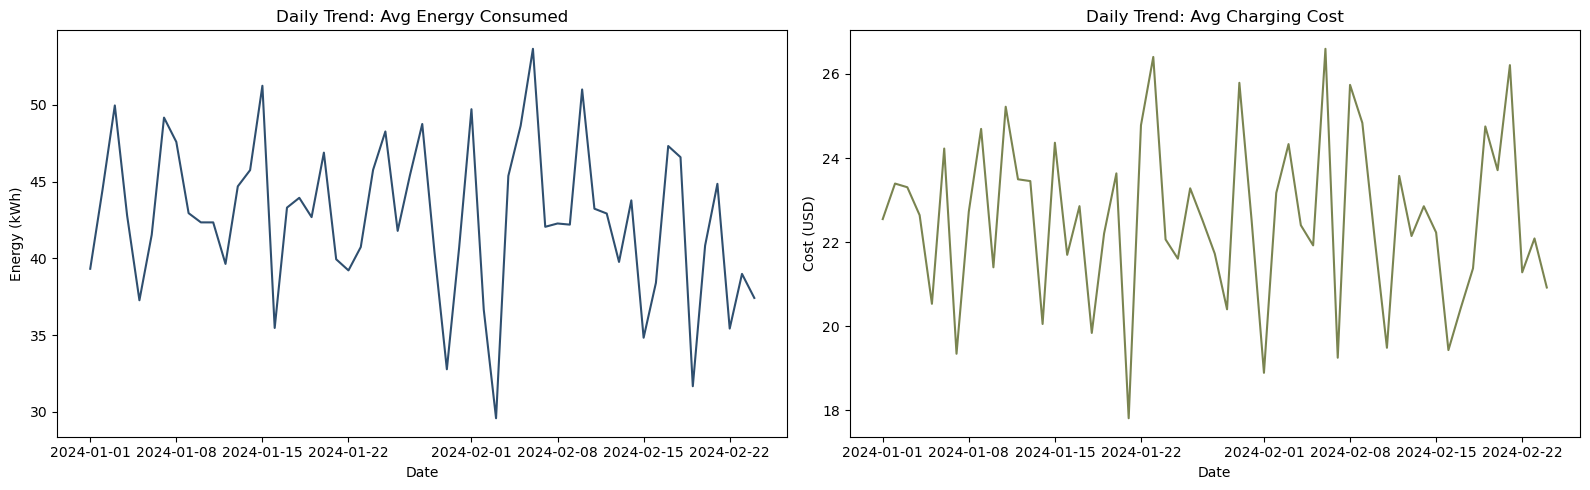

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

daily_energy = df.groupby(df["Charging Start Time"].dt.date)["Energy Consumed (kWh)"].mean()
daily_cost = df.groupby(df["Charging Start Time"].dt.date)["Charging Cost (USD)"].mean()

daily_energy.plot(kind="line", color="#2F4F6F", ax=axes[0])
axes[0].set_title("Daily Trend: Avg Energy Consumed")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Energy (kWh)")

daily_cost.plot(kind="line", color="#7A8450", ax=axes[1])
axes[1].set_title("Daily Trend: Avg Charging Cost")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Cost (USD)")

plt.tight_layout()
plt.show()


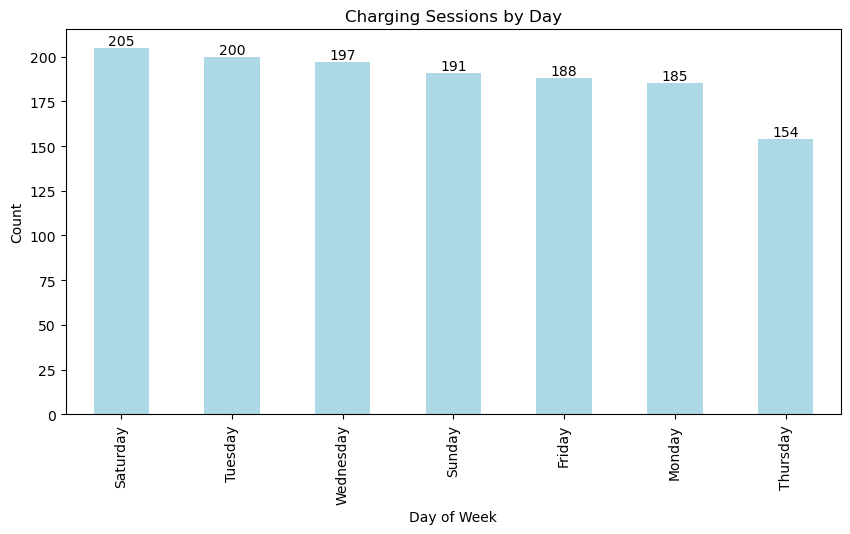

In [7]:

plt.figure(figsize=(10,5))   

ax = df["Day of Week"].value_counts().plot(
    kind="bar",
    color="#ADD8E6"
)

plt.title("Charging Sessions by Day")
plt.xlabel("Day of Week")
plt.ylabel("Count")

for i in ax.containers:
    ax.bar_label(i)

plt.show()

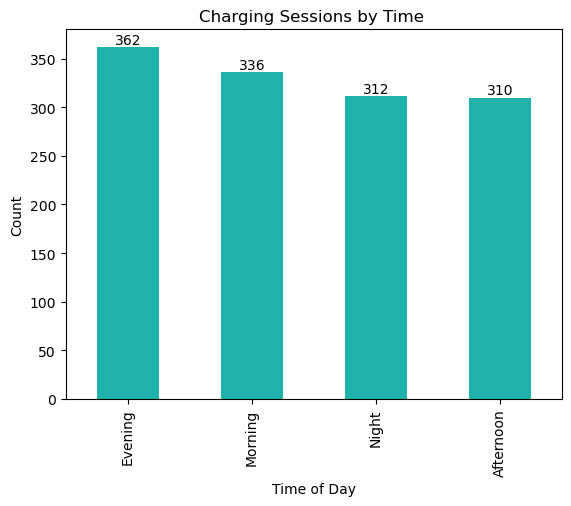

In [31]:
ax = df["Time of Day"].value_counts().plot(kind="bar", color="#20B2AA")

plt.title("Charging Sessions by Time ")
plt.xlabel("Time of Day")
plt.ylabel("Count")

for i in ax.containers:
    ax.bar_label(i)

plt.show()



<function matplotlib.pyplot.ylabel(ylabel: 'str', fontdict: 'dict[str, Any] | None' = None, labelpad: 'float | None' = None, *, loc: "Literal['bottom', 'center', 'top'] | None" = None, **kwargs) -> 'Text'>

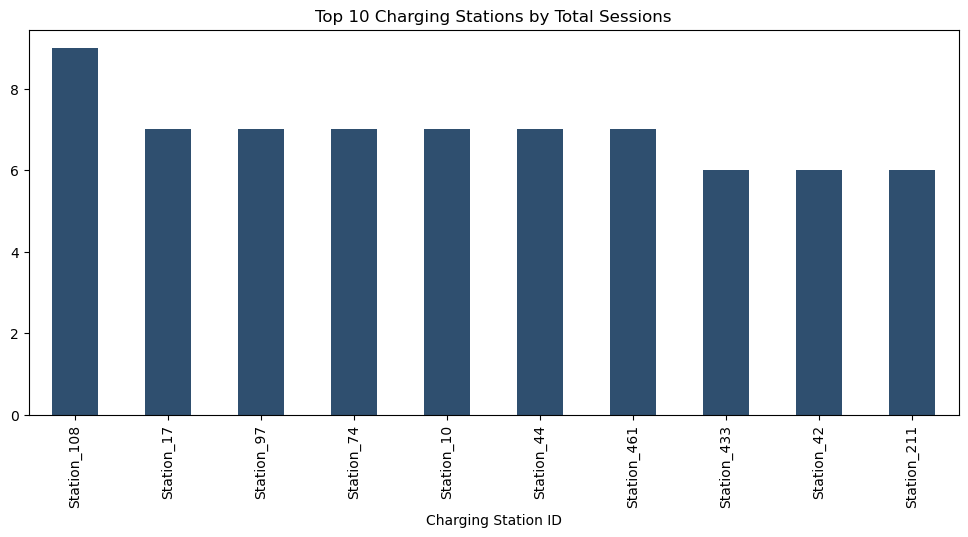

In [116]:
top_stations = df["Charging Station ID"].value_counts().head(10)

plt.figure(figsize=(12, 5))
top_stations.plot(kind="bar", color="#2F4F6F")
plt.title("Top 10 Charging Stations by Total Sessions")
plt.xlabel("Charging Station ID")
plt.ylabel


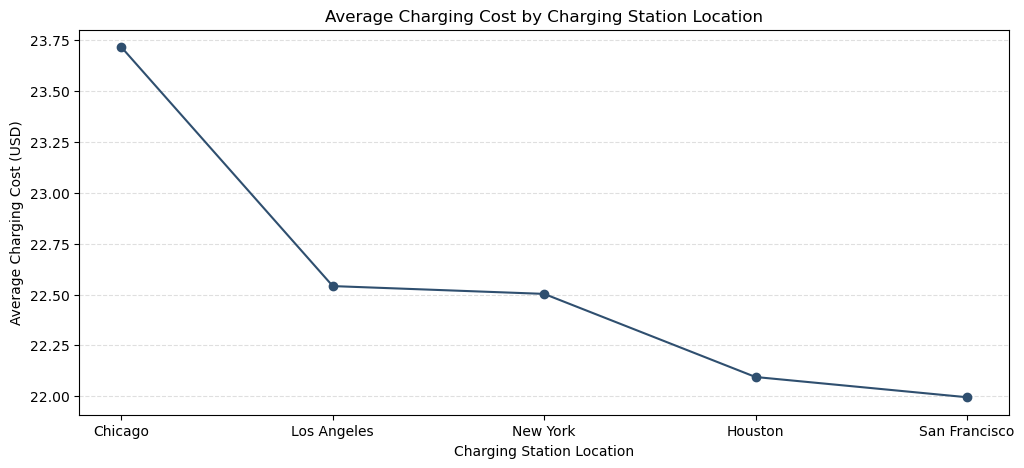

In [23]:
avg_cost = df.groupby("Charging Station Location")["Charging Cost (USD)"].mean() \
             .sort_values(ascending=False).head(6)

plt.figure(figsize=(12,5))
plt.plot(avg_cost.index, avg_cost.values, marker="o", color="#2F4F6F")

plt.title("Average Charging Cost by Charging Station Location")
plt.xlabel("Charging Station Location")
plt.ylabel("Average Charging Cost (USD)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()




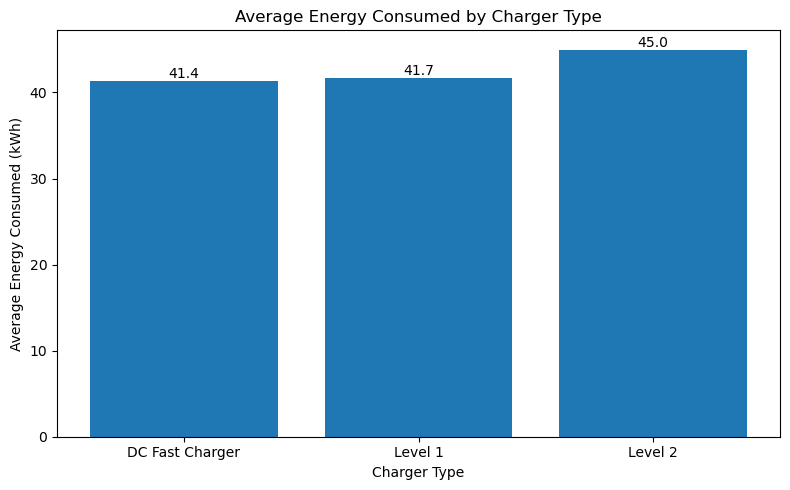

In [56]:
charger_energy = (
    df.groupby("Charger Type")["Energy Consumed (kWh)"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(8, 5))
plt.bar(charger_energy.index, charger_energy.values)

plt.title("Average Energy Consumed by Charger Type")
plt.xlabel("Charger Type")
plt.ylabel("Average Energy Consumed (kWh)")
for i, value in enumerate(charger_energy.values):
    plt.text(i, value, round(value, 1), ha='center', va='bottom')

plt.tight_layout()
plt.show()
